# Spectral density as a function of $4t$ for fixed $\mu$ #

In [16]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import h5py
import numpy as np
import class_utils as class_utils
import matplotlib
from class_grid import Grid
from class_params import Params
from class_groundstate import groundstate
from class_excitations import excitations
from class_vertices import vertices
from class_perturbation import perturbative
from class_self_energy import Self_Energy
from class_io import IO
from class_plotting import plot2D, plot_cns, plot_omega0
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.ticker as ticker
from scipy import interpolate

In [26]:
config_path = "config.yml" 

output_dir = class_utils.create_output_dir()
config = class_utils.read_config(config_path)

# load fixed density data 
dJUs_grid = np.loadtxt('./ragheed_data/dJU_values_nqcorr_1.csv',delimiter=',',skiprows=1).transpose()
muUs_grid = np.loadtxt('./ragheed_data/muU_values_nqcorr_1.csv',delimiter=',',skiprows=1)

# create interpolating function
f = interpolate.interp1d(dJUs_grid, muUs_grid)

Lx = config["grid"]["Lx"]
Ly = config["grid"]["Ly"]
cutoff = config["physics"]["cutoff"]
N = config["physics"]["N"]
UIB = config["physics"]["UIB"]
M = Lx * Ly

grid = Grid(Lx, Ly)
k_ind = int(Lx/2)+2
print(grid.KXs,grid.KXs[k_ind])

num_dJU = 300#100#200 # 100
dJU_max = 0.2154
dJU_min = 0.02871#0.1292
dJUs = np.linspace(dJU_min, dJU_max, num_dJU)#num_dJU)
muUs = f(dJUs)

[-3.06305284 -2.9059732  -2.74889357 -2.59181394 -2.43473431 -2.27765467
 -2.12057504 -1.96349541 -1.80641578 -1.64933614 -1.49225651 -1.33517688
 -1.17809725 -1.02101761 -0.86393798 -0.70685835 -0.54977871 -0.39269908
 -0.23561945 -0.07853982  0.07853982  0.23561945  0.39269908  0.54977871
  0.70685835  0.86393798  1.02101761  1.17809725  1.33517688  1.49225651
  1.64933614  1.80641578  1.96349541  2.12057504  2.27765467  2.43473431
  2.59181394  2.74889357  2.9059732   3.06305284] 0.39269908169872414


In [30]:
U_elems = np.zeros((len(dJUs), cutoff,cutoff), dtype='complex')
V_elems = np.zeros_like(U_elems)
W_elems = np.zeros_like(U_elems)

for count, dJU in enumerate(dJUs):
    muU = muUs[count]
    print(count,dJU,muU)
    params = Params(N, dJU, muU, UIB, cutoff)
    gs = groundstate(params)
    cns = gs.cns()
    n0 = gs.n0(cns)
    psi0 = gs.psi0(cns)
    exc = excitations(grid, params, gs, cns)
    uks, vks, omegaklambda = exc.calculate_matrices()
    verts = vertices(grid, gs, uks, vks, cns, n0)
    # pert = perturbative(grid, params, verts, omegaklambda)
    # print(n0, pert.sigma0(n0)/UIB)
    for i in range(0,cutoff):
        for j in range(0,cutoff):
            U_elems[count,i,j] = verts.U(k_ind,k_ind,i,-k_ind,-k_ind,j) 
            V_elems[count,i,j] = verts.V(k_ind,k_ind,i,-k_ind,-k_ind,j) 
            W_elems[count,i,j] = (verts.W(k_ind,k_ind,i,-k_ind,-k_ind,j) + np.conjugate(verts.W(-k_ind,-k_ind,j,k_ind,k_ind,i)))


0 0.02871 0.41421356237309515
1 0.029334381270903008 0.41421356237309515
2 0.02995876254180602 0.41421356237309515
3 0.03058314381270903 0.41421356237309515
4 0.03120752508361204 0.41421356237309515
5 0.03183190635451505 0.41421356237309515
6 0.03245628762541806 0.41421356237309515
7 0.03308066889632107 0.41421356237309515
8 0.03370505016722408 0.41421356237309515
9 0.03432943143812709 0.41421356237309515
10 0.0349538127090301 0.41421356237309515
11 0.03557819397993311 0.41421356237309515
12 0.03620257525083612 0.41421356237309515
13 0.03682695652173913 0.41421356237309515
14 0.03745133779264214 0.41421356237309515
15 0.03807571906354515 0.41421356237309515
16 0.038700100334448165 0.41421356237309515
17 0.03932448160535117 0.41421356237309515
18 0.03994886287625418 0.41421356237309515
19 0.04057324414715719 0.41421356237309515
20 0.0411976254180602 0.41421356237309515
21 0.041822006688963215 0.41421356237309515
22 0.04244638795986622 0.41421356237309515
23 0.04307076923076923 0.4142135

0 0
0 1
0 2
1 1
1 2
2 2


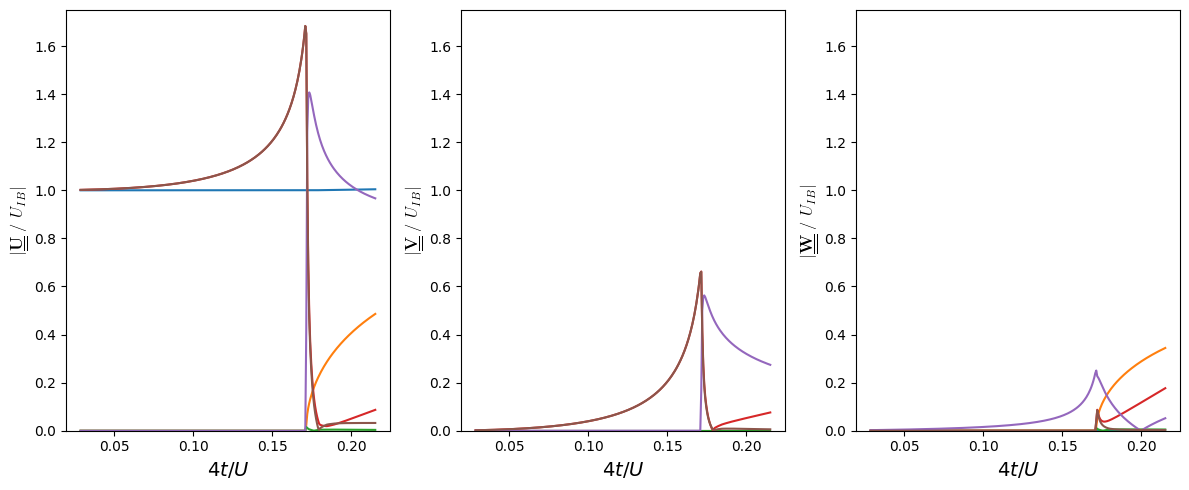

In [33]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols = 3, figsize = (12,5))
# i = 0
# j = 0
for i in range(0,cutoff):
    for j in range(i,cutoff):
        print(i,j)
        ax1.plot(dJUs,abs(U_elems[:,i,j]),'-')
        ax2.plot(dJUs,abs(V_elems[:,i,j]),'-')
        ax3.plot(dJUs,abs(W_elems[:,i,j]),'-')
ax1.set_xlabel(r'$4t/U$', fontsize=14)
ax2.set_xlabel(r'$4t/U$', fontsize=14)
ax3.set_xlabel(r'$4t/U$', fontsize=14)
ax1.set_ylim([0,1.75])
ax2.set_ylim([0,1.75])
ax3.set_ylim([0,1.75])
ax1.set_ylabel(r'$| \underline{\underline{\mathbf{U}}}\ /\ U_{IB} |$',fontsize = 12, usetex=True)
ax2.set_ylabel(r'$| \underline{\underline{\mathbf{V}}}\ /\ U_{IB} |$',fontsize = 12, usetex=True)
ax3.set_ylabel(r'$| \underline{\underline{\mathbf{W}}}\ /\ U_{IB} |$',fontsize = 12, usetex=True)
plt.tight_layout()

       

In [34]:
filename = f'../figs/vertices/dJU_{dJU}_Mu_{muU:.2f}_M_{grid.M}_N_{N}_cutoff_{cutoff}_opposite_momentum.pdf'

fig.savefig(filename, dpi=300, bbox_inches='tight')

In [29]:
# momentum scaling

U_elems_kk = np.zeros((Lx, cutoff,cutoff), dtype='complex')
V_elems_kk = np.zeros_like(U_elems_kk)
W_elems_kk = np.zeros_like(U_elems_kk)

muU = 0.3915859091748524
dJU = 0.4
print(muU,dJU)
params = Params(N, dJU, muU, UIB, cutoff)
gs = groundstate(params)
cns = gs.cns()
n0 = gs.n0(cns)
psi0 = gs.psi0(cns)
exc = excitations(grid, params, gs, cns)
uks, vks, omegaklambda = exc.calculate_matrices()
verts = vertices(grid, gs, uks, vks, cns, n0)
for i in range(0,cutoff):
    for j in range(0,cutoff):
        for kk in range(Lx):
            U_elems_kk[kk,i,j] = verts.U(kk,kk,i,-kk,-kk,j)
            V_elems_kk[kk,i,j] = verts.V(kk,kk,i,-kk,-kk,j) 
            W_elems_kk[kk,i,j] = (verts.W(kk,kk,i,-kk,-kk,j) + np.conjugate(verts.W(kk,kk,j,-kk,-kk,i)))

0.3915859091748524 0.4


0 0
0 1
0 2
1 1
1 2
2 2


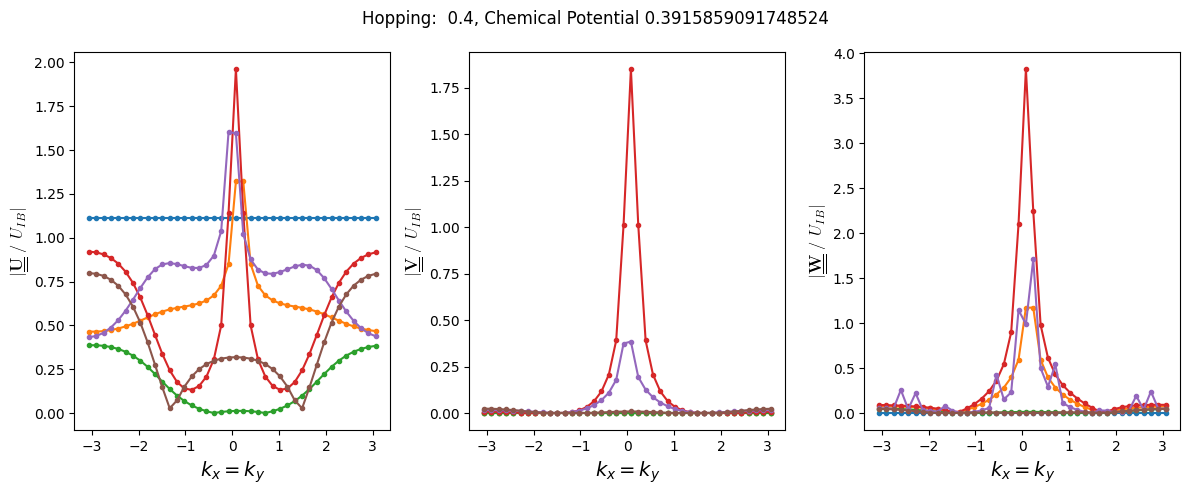

In [30]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols = 3, figsize = (12,5))

kks = range(Lx)
for i in range(0,cutoff):
    for j in range(i,cutoff):
        print(i,j)
        ax1.plot(grid.KXs,np.abs(U_elems_kk[:,i,j]),'.-')
        ax2.plot(grid.KXs,np.abs(V_elems_kk[:,i,j]),'.-')
        ax3.plot(grid.KXs,np.abs(W_elems_kk[:,i,j]),'.-')
ax1.set_xlabel(r'$k_x = k_y$', fontsize=14)
ax2.set_xlabel(r'$k_x = k_y$', fontsize=14)
ax3.set_xlabel(r'$k_x = k_y$', fontsize=14)
ax1.set_ylabel(r'$| \underline{\underline{\mathbf{U}}}\ /\ U_{IB} |$',fontsize = 12, usetex=True)
ax2.set_ylabel(r'$| \underline{\underline{\mathbf{V}}}\ /\ U_{IB} |$',fontsize = 12, usetex=True)
ax3.set_ylabel(r'$| \underline{\underline{\mathbf{W}}}\ /\ U_{IB} |$',fontsize = 12, usetex=True)
fig.suptitle(f'Hopping:  {dJU}, Chemical Potential {muU}')
plt.tight_layout()

In [2]:
import numpy as np
(np.sqrt(2) - 1)**2

0.17157287525381

In [28]:
np.shape(U_elems)

(1, 100, 100)

In [75]:
k_ind = 5
i = 1
j = 2
(verts.W(k_ind,k_ind,i,-k_ind,-k_ind,j) + np.conjugate(verts.W(-k_ind,-k_ind,j,k_ind,k_ind,i)))

0.008605492333423385